In [1]:
import pandas as pd
from glob import glob
import os
import json

In [2]:
dfs = []
json_paths_glob = os.path.join('logs', 'finetune_cpb_20250820', '*', '*', '*', '*', '*', '*', '*.json')
# Use glob to find all JSON files in the specified
# for json_path in glob('./logs/finetune_cpb_20250820/*/*/*/*/*/*/*.json'):
for json_path in glob(json_paths_glob):
    
    path_parts = json_path.split(os.sep)
    model = path_parts[2]
    weights = path_parts[3]
    method = path_parts[-5]
    n_train = int(path_parts[-4].split('_')[-1])
    rep = int(path_parts[-3].split('_')[-1])
    fold = int(path_parts[-2].split('_')[-1])
    
    # if model == 'unet' or weights == 'none':
        # continue
    
    # print(f'Processing {method} rep {rep} fold {fold} with {n_train} training samples')
    metrics_data = json.load(open(json_path, 'r'))
    metrics_data['model'] = model
    metrics_data['weights'] = weights
    metrics_data['method'] = method
    metrics_data['n_train'] = n_train
    metrics_data['rep'] = rep
    metrics_data['fold'] = fold
    dfs.append(pd.DataFrame(metrics_data, index=[0]))

metrics_df = pd.concat(dfs, ignore_index=True)
metrics_df = metrics_df.loc[(metrics_df['model'] == 'deeplabv3plus') & (metrics_df['weights'] == 'none')]
display(metrics_df)

ValueError: No objects to concatenate

In [3]:
metrics_df = pd.read_csv('./logs/finetune_cpb_20250820/summary.csv')
metrics_df = metrics_df.loc[(metrics_df['model'] == 'deeplabv3plus') & (metrics_df['weights'] == 'none')]
metrics_df

,accuracy,f1_score,precision,recall,jaccard,kappa,macro_f1_score,macro_precision,macro_recall,macro_jaccard,weighted_f1_score,weighted_precision,weighted_recall,weighted_jaccard,model,weights,method,n_train,rep,fold
0,0.799766,0.794376,0.801128,0.799766,0.688298,0.879217,0.492549,0.601150,0.491427,0.381148,0.794376,0.801128,0.799766,0.688298,deeplabv3plus,none,semss,250,0,1
1,0.818591,0.806523,0.805809,0.818591,0.705624,0.891824,0.538540,0.631617,0.523536,0.423227,0.806523,0.805809,0.818591,0.705624,deeplabv3plus,none,semss,250,0,2
2,0.823092,0.814340,0.814667,0.823092,0.714415,0.893741,0.554802,0.630005,0.535366,0.432958,0.814340,0.814667,0.823092,0.714415,deeplabv3plus,none,semss,250,0,3
3,0.800182,0.789364,0.792146,0.800182,0.682747,0.880718,0.489660,0.559125,0.484086,0.379805,0.789364,0.792146,0.800182,0.682747,deeplabv3plus,none,semss,250,0,4
4,0.817188,0.807178,0.806724,0.817188,0.707270,0.890719,0.524840,0.630042,0.500903,0.404353,0.807178,0.806724,0.817188,0.707270,deeplabv3plus,none,semss,250,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,0.832253,0.824302,0.822035,0.832253,0.727446,0.899419,0.577766,0.649648,0.551215,0.454426,0.824302,0.822035,0.832253,0.727446,deeplabv3plus,none,sss,750,8,4
416,0.834074,0.824392,0.822639,0.834074,0.728631,0.900675,0.550639,0.631967,0.531145,0.437288,0.824392,0.822639,0.834074,0.728631,deeplabv3plus,none,sss,750,9,1
417,0.825335,0.812891,0.814418,0.825335,0.714777,0.895990,0.533244,0.638901,0.509930,0.417665,0.812891,0.814418,0.825335,0.714777,deeplabv3plus,none,sss,750,9,2
418,0.819283,0.809536,0.808626,0.819283,0.709523,0.891662,0.508699,0.611146,0.501203,0.399690,0.809536,0.808626,0.819283,0.709523,deeplabv3plus,none,sss,750,9,3


In [19]:
metrics_df_sub = metrics_df.loc[metrics_df['n_train'] == 750]


metrics_df_pivot = metrics_df_sub.pivot_table(index=['method'], values='macro_jaccard', aggfunc='mean')

print(metrics_df_pivot.loc['semss'] - metrics_df_pivot.loc['srs'])
print(metrics_df_pivot.loc['semss'] - metrics_df_pivot.loc['sss'])
# for method in metrics_df_sub['method'].unique():
#     method_df = metrics_df_sub.loc[metrics_df_sub['method'] == method]
#     mean_iou = method_df['macro_jaccard'].mean()
#     std_iou = method_df['macro_jaccard'].std()
#     print(f'{method}: {mean_iou:.4f} ± {std_iou:.4f}')  
# metrics_df_sub.loc[metrics_df_sub['method'] == 'stratified_random', 'method'] = 'Stratified Random'

macro_jaccard    0.031075
dtype: float64
macro_jaccard    0.02505
dtype: float64


In [28]:
metrics_df[['method', 'n_train', 'fold', 'rep', 'macro_jaccard']]

,method,n_train,fold,rep,macro_jaccard
0,semss,250,1,0,0.381148
1,semss,250,2,0,0.423227
2,semss,250,3,0,0.432958
3,semss,250,4,0,0.379805
4,semss,250,1,1,0.404353
...,...,...,...,...,...
415,sss,750,4,8,0.454426
416,sss,750,1,9,0.437288
417,sss,750,2,9,0.417665
418,sss,750,3,9,0.399690


In [32]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- Method 1: Linear Mixed-Effects Model (Recommended) ---
# This model accounts for the non-independence of folds within each repetition.
# We treat 'method', 'n_train', and their interaction as fixed effects.
# We treat 'rep' as a random effect, acknowledging that measurements within the same 'rep' are correlated.
# The C(method) and C(n_train) syntax tells statsmodels to treat these as categorical variables.

print("--- Linear Mixed-Effects Model Results ---")
lmm = smf.mixedlm(
    "macro_jaccard ~ C(method) * C(n_train)", 
    metrics_df, 
    groups=metrics_df["rep"]
)
lmm_fit = lmm.fit()
print(lmm_fit.summary())


# --- Post-hoc analysis: Tukey's HSD ---
# After finding a significant effect, we can perform pairwise comparisons 
# to see which specific groups are different from each other.
# We'll perform this on the full dataset, considering all n_train levels.

# We need to create a new column that combines method and n_train
metrics_df['group'] = metrics_df['method'].astype(str) + '_' + metrics_df['n_train'].astype(str)

tukey_results = pairwise_tukeyhsd(
    endog=metrics_df['macro_jaccard'], 
    groups=metrics_df['group'], 
    alpha=0.05
)

print("\n--- Tukey's HSD Post-Hoc Test ---")
print(tukey_results)

# You can inspect the tukey_results table. The 'reject' column will be 'True' 
# for pairs of groups that are significantly different. For example, you can look for
# comparisons like 'semss_750' vs 'srs_750' and 'semss_750' vs 'sss_750'.

--- Linear Mixed-Effects Model Results ---
                    Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       macro_jaccard
No. Observations:       420           Method:                   REML         
No. Groups:             10            Scale:                    0.0007       
Min. group size:        42            Log-Likelihood:           902.3302     
Max. group size:        42            Converged:                Yes          
Mean group size:        42.0                                                 
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.379    0.004 91.833 0.000  0.371  0.387
C(method)[T.srs]                   -0.008    0.006 -1.329 0.184 -0.019  0.004
C(method)[T.sss]                   -0.010

/Users/dak/.virtualenvs/MSLC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



--- Tukey's HSD Post-Hoc Test ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
semss_250 semss_500   0.0431    0.0  0.0266  0.0595   True
semss_250 semss_750   0.0644    0.0  0.0464  0.0825   True
semss_250   srs_250  -0.0077 0.9237 -0.0257  0.0104  False
semss_250   srs_500   0.0211 0.0024  0.0047  0.0376   True
semss_250   srs_750   0.0334    0.0  0.0153  0.0514   True
semss_250   sss_250  -0.0099 0.7348 -0.0279  0.0081  False
semss_250   sss_500   0.0199 0.0059  0.0034  0.0363   True
semss_250   sss_750   0.0394    0.0  0.0214  0.0574   True
semss_500 semss_750   0.0214  0.002  0.0049  0.0378   True
semss_500   srs_250  -0.0507    0.0 -0.0672 -0.0343   True
semss_500   srs_500   -0.022 0.0001 -0.0367 -0.0073   True
semss_500   srs_750  -0.0097 0.6534 -0.0262  0.0067  False
semss_500   sss_250   -0.053    0.0 -0.0695 -0.0366   True
semss_500   sss_500  

In [54]:
# metrics_df_750 = metrics_df.loc[metrics_df['n_train'] == 750][['macro_jaccard', 'method', 'rep']]
metrics_df_750 = metrics_df[['macro_jaccard', 'method', 'rep', 'n_train']]
metrics_df_750 = metrics_df_750.groupby(['rep', 'method', 'n_train']).mean()
metrics_df_750 = metrics_df_750.reset_index()

anova = sm.stats.anova_lm(sm.OLS.from_formula('macro_jaccard ~ C(method) + C(n_train) + C(method):C(n_train)', data=metrics_df_750.reset_index()).fit(), typ=2)


metrics_df_750['group'] = metrics_df_750['method'].astype(str) + '_' + metrics_df_750['n_train'].astype(str)

tukey_results_avg = pairwise_tukeyhsd(
    endog=metrics_df_750['macro_jaccard'], 
    # groups=metrics_df_750['method'], 
    groups=metrics_df_750['group'],
    alpha=0.05
)

display(anova)
display(tukey_results_avg.summary())


,sum_sq,df,F,PR(>F)
C(method),0.007863,2.0,22.263221,1.971818e-08
C(n_train),0.041223,2.0,116.719290,1.391369e-24
C(method):C(n_train),0.001520,4.0,2.151566,8.189045e-02
Residual,0.014304,81.0,NaN,NaN


group1,group2,meandiff,p-adj,lower,upper,reject
semss_250,semss_500,0.0431,0.0,0.0241,0.062,True
semss_250,semss_750,0.0644,0.0,0.0455,0.0834,True
semss_250,srs_250,-0.0077,0.9321,-0.0266,0.0113,False
semss_250,srs_500,0.0211,0.0176,0.0022,0.0401,True
semss_250,srs_750,0.0334,0.0,0.0144,0.0523,True
semss_250,sss_250,-0.0099,0.7621,-0.0289,0.009,False
semss_250,sss_500,0.0199,0.0325,0.0009,0.0388,True
semss_250,sss_750,0.0394,0.0,0.0204,0.0583,True
semss_500,semss_750,0.0214,0.0155,0.0024,0.0403,True
semss_500,srs_250,-0.0507,0.0,-0.0697,-0.0318,True


In [66]:
tukey_df = pd.DataFrame(tukey_results_avg._results_table.data[1:], columns=tukey_results_avg._results_table.data[0])
tukey_df.loc[tukey_df['reject'] == True]

for n_train in metrics_df_750['n_train'].unique():
    display(tukey_df.loc[(tukey_df['group1'].str.endswith(f'_{n_train}')) & (tukey_df['group2'].str.endswith(f'_{n_train}'))])

,group1,group2,meandiff,p-adj,lower,upper,reject
2,semss_250,srs_250,-0.0077,0.9321,-0.0266,0.0113,False
5,semss_250,sss_250,-0.0099,0.7621,-0.0289,0.0090,False
23,srs_250,sss_250,-0.0023,1.0000,-0.0212,0.0167,False


,group1,group2,meandiff,p-adj,lower,upper,reject
10,semss_500,srs_500,-0.0220,0.0113,-0.0409,-0.0030,True
13,semss_500,sss_500,-0.0232,0.0058,-0.0422,-0.0043,True
28,srs_500,sss_500,-0.0012,1.0000,-0.0202,0.0177,False


,group1,group2,meandiff,p-adj,lower,upper,reject
17,semss_750,srs_750,-0.0311,0.0000,-0.0500,-0.0121,True
20,semss_750,sss_750,-0.0250,0.0020,-0.0440,-0.0061,True
32,srs_750,sss_750,0.0060,0.9835,-0.0129,0.0250,False


In [67]:
# metrics_df.loc[(metrics_df.weights == 'none') & (metrics_df.rep <= 1)].groupby(['model', 'weights', 'method', 'n_train']).max().sort_values(by='macro_jaccard', ascending=False)
metrics_df.groupby(['model', 'weights', 'method', 'n_train']).mean().sort_values(by='macro_jaccard', ascending=False)[['accuracy', 'macro_jaccard']]

accuracy  macro_jaccard
model         weights method n_train                         
deeplabv3plus none    semss  750      0.824348       0.443704
                             500      0.820717       0.422349
                      sss    750      0.825424       0.418654
                      srs    750      0.822443       0.412629
                             500      0.818749       0.400382
                      sss    500      0.818748       0.399135
                      semss  250      0.797839       0.379271
                      srs    250      0.806527       0.371619
                      sss    250      0.805061       0.369341

C:\Users\dh2306\AppData\Local\Temp\ipykernel_54564\3028859740.py:21: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False, dodge=False, alpha=0.5, linewidth=1, edgecolor='gray', size=6)
C:\Users\dh2306\AppData\Local\Temp\ipykernel_54564\3028859740.py:21: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False, dodge=False, alpha=0.5, linewidth=1, edgecolor='gray', size=6)
C:\Users\dh2306\AppData\Local\Temp\ipykernel_54564\3028859740.py:21: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df[df.n_tra

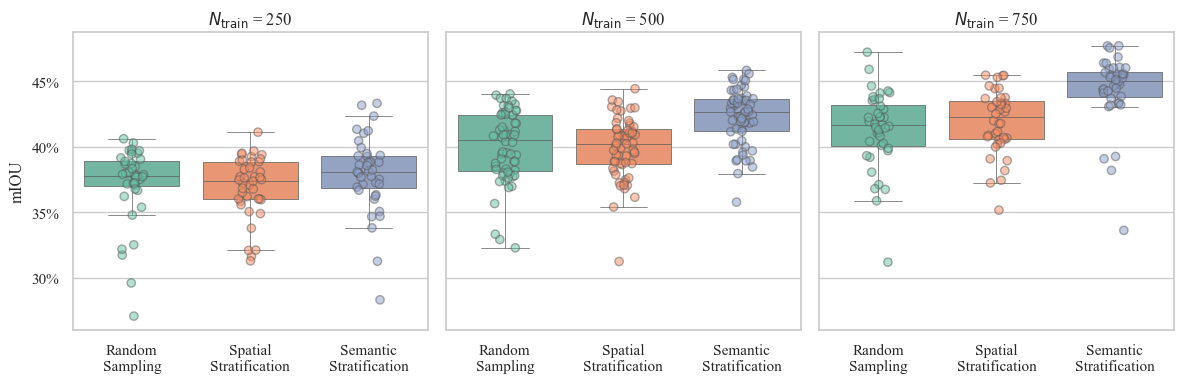

In [95]:
# create boxplot
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Times New Roman'



df = metrics_df.copy()
df['method'] = df['method'].map({'srs': 'Random\nSampling', 'sss': 'Spatial\nStratification', 'semss': 'Semantic\nStratification'})
df['method'] = pd.Categorical(df['method'], categories=['Random\nSampling', 'Spatial\nStratification', 'Semantic\nStratification'], ordered=True)
# df = df.loc[(df.model == 'unet') & (df.weights == 'none')]

# df = df[df.weights == 'none']
# df = df.loc[df.rep <= 0]
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
n_train_values = [250, 500, 750]
for i, n_train in enumerate(n_train_values):
    sns.boxplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False, showfliers=False, linewidth=0.5)
    sns.stripplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False, dodge=False, alpha=0.5, linewidth=1, edgecolor='gray', size=6)
    # sns.violinplot(data=df[df.n_train == n_train], x='method', y='macro_jaccard', ax=ax[i], palette='Set2', hue='method', legend=False,)
    # ax[i].set_title(f'n_train = {n_train}')
    ax[i].set_title(r'$N_{\text{train}}$ = ' + str(n_train))    # ax[i].set_ylabel('Macro Jaccard')
    ax[i].set_xlabel('')
    ax[i].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))


ax[0].set_ylabel('mIOU')
fig.tight_layout()

plt.savefig('./paper/images/cpb_sampling_methods_boxplot.png', dpi=300)
plt.savefig('./paper/images/cpb_sampling_methods_boxplot.pdf')
plt.show()
# for i, n_train in enumerate(n_train_values):
#     sns.boxplot(data=df[df.n_train == n_train], x='method', y='accuracy', ax=ax[1][i], palette='Set2', hue='method', legend=False)
#     ax[1][i].set_title(f'n_train = {n_train}')
#     ax[1][i].set_ylabel('Overall Accuracy')
#     ax[1][i].set_xlabel('Method')

<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:34: SyntaxWarning: invalid escape sequence '\D'
C:\Users\dh2306\AppData\Local\Temp\ipykernel_54564\3872174025.py:34: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$ mIOU')
C:\Users\dh2306\AppData\Local\Temp\ipykernel_54564\3872174025.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2', dodge=True, alpha=0.5, linewidth=1, edgecolor='gray', size=6, legend=False, ax=ax)


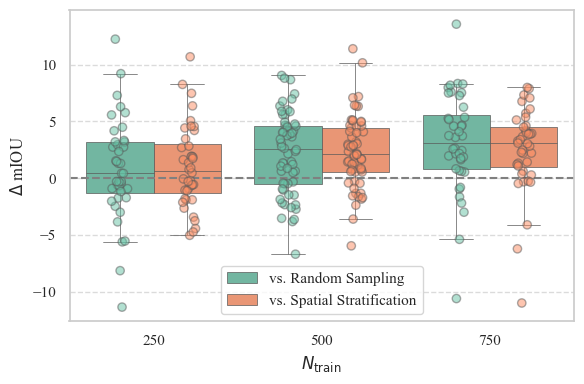

In [123]:

# Create a plot to emphasize the performance gain of SEMSS
df = metrics_df.copy()
df_pivot = df.pivot_table(index=['n_train', 'rep', 'fold'], columns='method', values='macro_jaccard').reset_index()

# Calculate the performance gain of semss over the other methods and convert to percent
df_pivot['semss_gain_vs_srs'] = (df_pivot['semss'] - df_pivot['srs']) * 100
df_pivot['semss_gain_vs_sss'] = (df_pivot['semss'] - df_pivot['sss']) * 100

# Melt the dataframe to make it suitable for plotting with seaborn
df_gain = df_pivot.melt(
    id_vars=['n_train'], 
    value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
    var_name='comparison',
    value_name='macro_f1_score_gain'
)
df_gain['comparison'] = df_gain['comparison'].map({
    'semss_gain_vs_srs': 'vs. Random Sampling',
    'semss_gain_vs_sss': 'vs. Spatial Stratification'
})
df_gain['comparison'] = pd.Categorical(df_gain['comparison'], categories=['vs. Random Sampling', 'vs. Spatial Stratification'], ordered=True)

# Create the plot
# plt.figure(figsize=(8, 4))
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# sns.boxplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2')
# sns.violinplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2', split=True, inner='quartile', cut=0)
sns.boxplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2', showfliers=False, linewidth=0.5, ax=ax)
sns.stripplot(data=df_gain, x='n_train', y='macro_f1_score_gain', hue='comparison', palette='Set2', dodge=True, alpha=0.5, linewidth=1, edgecolor='gray', size=6, legend=False, ax=ax)

ax.axhline(0, color='grey', linestyle='--')
# ax.set_title('Performance Gain of Semantic Stratification vs. Other Methods')
# ax.set_xlabel('Number of Training Samples')
ax.set_xlabel(r'$N_{\text{train}}$')
ax.set_ylabel('$\Delta$ mIOU')
# plt.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
# ax.yaxis.set_major_formatter(PercentFormatter(0.01, decimals=0))
plt.legend(title=None)
plt.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()

plt.savefig('./paper/images/cpb_sampling_methods_performance_gain_boxplot.png', dpi=300)
plt.savefig('./paper/images/cpb_sampling_methods_performance_gain_boxplot.pdf')
plt.show()


In [8]:
# show differences between methods on a per model/weights basis
df = metrics_df.copy()
df = df.loc[df.rep <= 0]
df
df_pivot = df.pivot_table(index=['model', 'weights', 'n_train'], 
                                   columns='method', 
                                   values='macro_f1_score').reset_index()
# df_pivot = df_pivot.sort_values(by='macro_jaccard', ascending=False)
# display(df_pivot)

df_pivot['semss_gain_vs_srs'] = (df_pivot['semss'] - df_pivot['srs']) * 100
df_pivot['semss_gain_vs_sss'] = (df_pivot['semss'] - df_pivot['sss']) * 100
# df_pivot = df_pivot.melt(
#     id_vars=['model', 'weights', 'n_train'], 
#     value_vars=['semss_gain_vs_srs', 'semss_gain_vs_sss'],
#     var_name='comparison',
#     value_name='macro_jaccard_gain'
# )

# df_pi
df_pivot['min_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].min(axis=1)
df_pivot['max_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].max(axis=1)
df_pivot['med_gain'] = df_pivot[['semss_gain_vs_srs', 'semss_gain_vs_sss']].median(axis=1)

df_pivot.groupby(['model', 'weights', 'n_train']).mean().sort_values(by=['weights', 'med_gain'], ascending=False)
    

method                    semss       srs       sss  semss_gain_vs_srs  \
model weights n_train                                                    
none  sss     250           NaN       NaN  0.444367                NaN   
              500           NaN       NaN  0.507537                NaN   
              750           NaN       NaN  0.534822                NaN   
      srs     250           NaN  0.477151       NaN                NaN   
              500           NaN  0.534841       NaN                NaN   
              750           NaN  0.506672       NaN                NaN   
      semss   250      0.518888       NaN       NaN                NaN   
              500      0.554617       NaN       NaN                NaN   
              750      0.595899       NaN       NaN                NaN   

method                 semss_gain_vs_sss  min_gain  max_gain  med_gain  
model weights n_train                                                   
none  sss     250                    NaN       NaN       NaN       NaN  
              500                    NaN       NaN       NaN       NaN  
              750                    NaN       NaN       NaN       NaN  
      srs     250                    NaN       NaN       NaN       NaN  
              500                    NaN       NaN       NaN       NaN  
              750                    NaN       NaN       NaN       NaN  
      semss   250                    NaN       NaN       NaN       NaN  
              500                    NaN       NaN       NaN       NaN  
              750                    NaN       NaN       NaN       NaN

In [127]:
from mslandcover.config import LEGEND_COLORS_RGBA
from glob import glob
import rasterio as rio

paths = glob('./data/splits/split_*/target/*.tif')
for path in paths:
    with rio.open(path, 'r+') as src:
        src.write_colormap(1, LEGEND_COLORS_RGBA)
# for path in glob('./data/splits/*/target/*.tif'):
#     print(path)

In [ ]:
#  convert to png for easier viewing
from PIL import Image
for path in paths:
    with rio.open(path) as src:
        img = src.read(1)
        img_color = src.colormap(1)
        img_color_mapped = Image.new('RGBA', img.shape[::-1])
        pixels = img_color_mapped.load()
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                pixels[j, i] = img_color.get(img[i, j], (0, 0, 0, 0))  # Default to transparent if no color defined
        output_path = path.replace('.tif', '.png').replace('target', 'target_png')
        # print(f'Saving {output_path}')
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        img_color_mapped.save(output_path)



In [131]:
paths = glob('./data/splits/split_*/input/*.tif')
for path in paths:
    with rio.open(path) as src:
        img = src.read([4, 1, 2])
        # Normalize and convert to 8-bit per channel
        # img_min = img.min(axis=(1, 2), keepdims=True)
        # img_max = img.max(axis=(1, 2), keepdims=True)
        # img_normalized = ((img - img_min) / (img_max - img_min) * 255).astype('uint8')
        # img_rgb = Image.fromarray(img_normalized.transpose(1, 2, 0), 'RGB')
        img = Image.fromarray(img.transpose(1, 2, 0), 'RGB')
        output_path = path.replace('.tif', '.png').replace('input', 'input_png')
        # print(f'Saving {output_path}')
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        img.save(output_path)

In [152]:
# create a random confusion matrix grid with gray squares and transparent background for icon
from PIL import Image, ImageDraw
import numpy as np
size = 100
confusion_matrix_icon = Image.new('RGBA', (size, size), (255, 255, 255, 0))  # Transparent background
draw = ImageDraw.Draw(confusion_matrix_icon)
for i in range(10):
    for j in range(10):
        gray_value = 256 - np.random.randint(0, 50)  # Random gray value between 100 and 255
        if i != j:
            draw.rectangle([i*10, j*10, (i+1)*10, (j+1)*10], fill=(gray_value , gray_value , gray_value , 255))
        else:
            gray_value = 256 - np.random.randint(150, 256)  # Lighter gray for diagonal
            draw.rectangle([i*10, j*10, (i+1)*10, (j+1)*10], fill=(gray_value , gray_value , gray_value , 255))

# resample
        
confusion_matrix_icon.save('./paper/images/confusion_matrix_icon.png', dpi=(300, 300))
# confusion_matrix_icon.show()11